# Experiment1-Applying Python to process data learning

**Name:** JiaxinLIN 林嘉馨
**Student ID:** 23302040  
**Experiment Title:** Applying Python to process data learning  
**Institution:** School of Material, SYSU  

---

# Abstract
*本实验旨在通过Python工具掌握材料数据的获取与分析方法，提升AI辅助材料设计的基础能力。实验首先基于pymatgen库调用Materials Project API，检索并分析ABO₃型化合物的关键物性数据，包括带隙、形成能和能量高于凸包等参数，并利用pandas进行结构化处理和统计可视化。随后，从Figshare平台获取OQMD钙钛矿数据集，对原始数据进行清洗、类型转换及有效性筛选，完成形成能分布分析。最后，对两个数据库中共有化学式的数据进行交叉比较，使用t检验评估形成能差异的显著性。通过本实验，我系统掌握了Python在材料数据分析中的核心流程，深化了对材料数据特征、稳定性判断及统计分析方法的理解，为后续的机器学习与模型构建研究奠定了基础。*

# Q1-Materials Project data-MP

#### 1.Execute the query and convert the data into the Pandas DataFrame format

In [1]:
import sys
import pandas as pd
import pprint
from mp_api.client import MPRester

In [2]:
import os
fields=[
            "material_id",
            "formula_pretty",
            "nsites",
            "band_gap",
            "formation_energy_per_atom",
            "theoretical",
            "energy_above_hull",
        ]

##执行查询
with MPRester(os.environ.get("MP_API_KEY")) as mpr: #密码
    docs = mpr.materials.summary.search(
    chemsys="*-*-O",
    formula="**O3",
    fields=fields,
)


##将数据转化为Pandas DataFrame
data = [doc.dict() for doc in docs]
df = pd.DataFrame(data)
df = df[fields]

pprint.pprint(df)

Retrieving SummaryDoc documents:   0%|          | 0/2672 [00:00<?, ?it/s]

     material_id formula_pretty  nsites  band_gap  formation_energy_per_atom  \
0       mp-bjqvu           H3NO      20    0.2875                  -0.075317   
1       mp-bjqvv           H3NO      20    2.4233                  -0.675641   
2       mp-bmnoz          TaOF3      25    2.1533                  -3.228941   
3       mp-bralx           VOF3      20    2.8760                  -2.686271   
4       mp-bseqj           VOF3      20    2.9487                  -2.686984   
...          ...            ...     ...       ...                        ...   
2667      mp-gla          KNbO3       5    1.4760                  -2.850938   
2668    mp-bfazq         CoBiO3       5    0.0000                  -1.458913   
2669      mp-iwg         BaTiO3       5    1.7280                  -3.490321   
2670    mp-brgvg          KTiO3       5    0.0000                  -2.662460   
2671    mp-cevcv         CaTcO3       5    0.0000                  -2.366164   

      theoretical  energy_above_hull  


In [3]:
volid_data=df.dropna() #确保数据有效
volid_data

,material_id,formula_pretty,nsites,band_gap,formation_energy_per_atom,theoretical,energy_above_hull
0,mp-bjqvu,H3NO,20,0.2875,-0.075317,True,0.806157
1,mp-bjqvv,H3NO,20,2.4233,-0.675641,True,0.205833
2,mp-bmnoz,TaOF3,25,2.1533,-3.228941,True,0.279460
3,mp-bralx,VOF3,20,2.8760,-2.686271,True,0.026382
4,mp-bseqj,VOF3,20,2.9487,-2.686984,True,0.025669
...,...,...,...,...,...,...,...
2667,mp-gla,KNbO3,5,1.4760,-2.850938,False,0.001190
2668,mp-bfazq,CoBiO3,5,0.0000,-1.458913,False,0.000000
2669,mp-iwg,BaTiO3,5,1.7280,-3.490321,False,0.001957
2670,mp-brgvg,KTiO3,5,0.0000,-2.662460,True,0.089448


#### 2.Statisitcs
- Total number of ABO3-type compounds in the Materials Project database
- unique (non - repeating) ABO3 chemical formulas
- average counts of crystals (i.e., polymorphs) correspond to each ABO3 chemical formula

In [4]:
total_entries = len(df)

print(f"Total number of ABO3 entries: {total_entries}")
print(f"Number of unique ABO3 formulas: {df['formula_pretty'].nunique()}")

Total number of ABO3 entries: 2672
Number of unique ABO3 formulas: 1390


In [5]:
#计算ABO3平均polymorphs的个数

#计算每个化学式polymorphs的个数
formula_counts = df['formula_pretty'].value_counts()

#计算平均值
average_polymorphs = formula_counts.mean()

print(f"Average number of polymorphs per ABO3 formula: {average_polymorphs:.2f}")

#展示具有较多多polymorphs的化学式
print("\nTop 10 ABO3 formulas with the highest number of polymorphs:")
print(formula_counts.head(10).to_string())

Average number of polymorphs per ABO3 formula: 1.92

Top 10 ABO3 formulas with the highest number of polymorphs:
formula_pretty
MgSiO3    37
VOF3      23
VCrO3     21
LaMnO3    20
NaNbO3    20
CaCO3     16
FeBiO3    16
CaSiO3    14
LaAlO3    13
LaCoO3    12


#### 3.Fraction of non-theoretical (experimentally known) ABO3 compounds

In [6]:
#非理论预测性 ABO₃ 化合物在总数据中的比例（百分比）
non_theoretical_entries = len(df[df["theoretical"] == False])#非理论预测性 ABO₃ 化合物

fraction_non_theoretical = non_theoretical_entries/total_entries*100 #占比

print(f"Fraction of non-theoretical (experimentally known) ABO3 compounds: {fraction_non_theoretical:.2f}%")
print(f"({non_theoretical_entries} out of {total_entries} total entries)")

Fraction of non-theoretical (experimentally known) ABO3 compounds: 32.90%
(879 out of 2672 total entries)


#### 4.Add column for formation energy in J/mol

$$
1 \text{ eV} = 1.602176634 \times 10^{-19} \text{ J}
$$
$$
1 \text{ mol} = 6.02214076 \times 10^{23} \text{ atoms}
$$

所以:

$$
1 \text{ eV} / \text{atom} = 1.602176634 \times 10^{-19} \times 6.02214076 \times 10^{23} = 96485.33212 \text{ J} / \text{mol}
$$

In [7]:
# conversion factor from eV/atom to J/mol
EV_PER_ATOM_TO_J_PER_MOL = 96_485.33212  # exact constant

df["formation_energy_J_per_mol"] = df["formation_energy_per_atom"] * EV_PER_ATOM_TO_J_PER_MOL

print("Added new column: 'formation_energy_J_per_mol'")
pprint.pprint(df)

Added new column: 'formation_energy_J_per_mol'
     material_id formula_pretty  nsites  band_gap  formation_energy_per_atom  \
0       mp-bjqvu           H3NO      20    0.2875                  -0.075317   
1       mp-bjqvv           H3NO      20    2.4233                  -0.675641   
2       mp-bmnoz          TaOF3      25    2.1533                  -3.228941   
3       mp-bralx           VOF3      20    2.8760                  -2.686271   
4       mp-bseqj           VOF3      20    2.9487                  -2.686984   
...          ...            ...     ...       ...                        ...   
2667      mp-gla          KNbO3       5    1.4760                  -2.850938   
2668    mp-bfazq         CoBiO3       5    0.0000                  -1.458913   
2669      mp-iwg         BaTiO3       5    1.7280                  -3.490321   
2670    mp-brgvg          KTiO3       5    0.0000                  -2.662460   
2671    mp-cevcv         CaTcO3       5    0.0000                  -2.366

#### 5.Total number of materials in each stability–band-gap category

In [8]:
#依据稳定性和能带区分ABO3材料

#区分稳定性
def classify_stability(e_above_hull):
    if e_above_hull>0.03:
        return "Unstable"
    else:
        return "Potentially Stable"

#区分能隙
def classify_band_gap(Eg):
    if Eg==0:
        return "Metallic"
    elif 0<Eg<=1:
        return "Small Band Gap"
    else:
        return "Large Band Gap"


#将定义的函数作用于原来的数据库，并创建新列
df["stability_class"]=df["energy_above_hull"].apply(classify_stability)
df["band_gap_class"]=df["band_gap"].apply(classify_band_gap)

#创建统计表
classification_table_with_totals=pd.crosstab(
    df["stability_class"],
    df["band_gap_class"],
    margins=True,  #在交叉表中自动添加“合计（Total）”行和列
    margins_name="Total"
)

print("\nTotal number of materials in each stability–band-gap category:")
print(classification_table_with_totals)     


Total number of materials in each stability–band-gap category:
band_gap_class      Large Band Gap  Metallic  Small Band Gap  Total
stability_class                                                    
Potentially Stable             563       189             116    868
Unstable                       508      1069             227   1804
Total                         1071      1258             343   2672


#### 6.Plot
- Distribution of formation energy per atom
- Distribution of band gaps

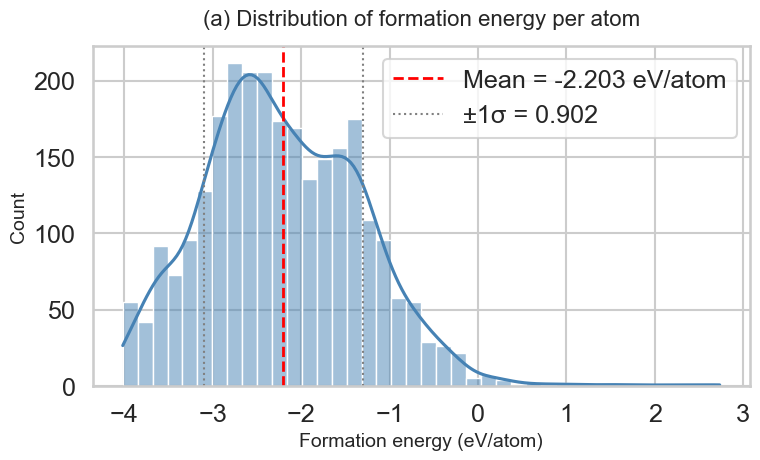

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置Seaborn样式
sns.set(style="whitegrid", context="talk", font_scale=1.1)

# ---- (a) Formation Energy Distribution ----
plt.figure(figsize=(8, 5))
sns.histplot(df["formation_energy_per_atom"], bins=40, kde=True, color="steelblue")

# 计算平均值与标准差
mean_fe = df["formation_energy_per_atom"].mean()
std_fe = df["formation_energy_per_atom"].std()

# 添加竖线和注释
plt.axvline(mean_fe, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_fe:.3f} eV/atom")
plt.axvline(mean_fe + std_fe, color="gray", linestyle=":", linewidth=1.5, label=f"±1σ = {std_fe:.3f}")
plt.axvline(mean_fe - std_fe, color="gray", linestyle=":", linewidth=1.5)

# 标注与图表美化
plt.xlabel("Formation energy (eV/atom)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("(a) Distribution of formation energy per atom", fontsize=16, pad=15)
plt.legend()
plt.tight_layout()
plt.show()

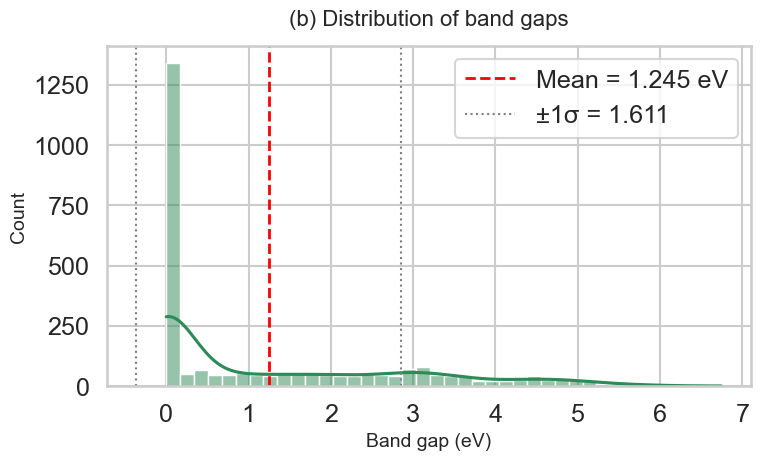

In [10]:
# ---- (b) Band Gap Distribution ----
plt.figure(figsize=(8, 5))
sns.histplot(df["band_gap"], bins=40, kde=True, color="seagreen")

# 计算平均值与标准差
mean_bg = df["band_gap"].mean()
std_bg = df["band_gap"].std()

# 添加竖线和注释
plt.axvline(mean_bg, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_bg:.3f} eV")
plt.axvline(mean_bg + std_bg, color="gray", linestyle=":", linewidth=1.5, label=f"±1σ = {std_bg:.3f}")
plt.axvline(mean_bg - std_bg, color="gray", linestyle=":", linewidth=1.5)

# 标注与图表美化
plt.xlabel("Band gap (eV)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("(b) Distribution of band gaps", fontsize=16, pad=15)
plt.legend()
plt.tight_layout()
plt.show()

# Q2-Publicly available research data-OQMD

In [11]:
df_oqmd = pd.read_csv("https://ndownloader.figshare.com/files/9158587")
df_oqmd

,Chemical formula,A,B,In literature,Valence A,Valence B,Radius A [ang],Radius B [ang],Lowest distortion,Formation energy [eV/atom],...,Magnetic moment [mu_B],Volume per atom [A^3/atom],Band gap [eV],a [ang],b [ang],c [ang],alpha [deg],beta [deg],gamma [deg],Vacancy energy [eV/O atom]
0,Ac2O3,Ac,Ac,False,element not in BV,element not in BV,1.12,1.12,cubic,-2.732,...,0.000,20.836,0.332,4.705,4.705,4.705,90.0,90.0,90.0,3.150
1,AcAgO3,Ac,Ag,False,element not in BV,element not in BV,1.12,0.95,orthorhombic,-1.957,...,0.000,14.485,0.000,5.779,6.077,8.248,90.0,90.0,90.0,0.817
2,AcAlO3,Ac,Al,False,element not in BV,element not in BV,1.12,0.54,cubic,-3.532,...,0.000,11.487,4.307,3.858,3.858,3.858,90.0,90.0,90.0,6.695
3,AcAsO3,Ac,As,False,element not in BV,element not in BV,1.12,0.52,orthorhombic,-2.398,...,0.000,14.355,0.000,5.780,6.012,8.262,90.0,90.0,90.0,3.634
4,AcAuO3,Ac,Au,False,element not in BV,element not in BV,1.12,0.93,orthorhombic,-2.006,...,0.000,15.190,0.745,5.899,6.750,7.630,90.0,90.0,90.0,0.807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,ZrWO3,Zr,W,False,1,5,0.89,0.62,cubic,-1.637,...,0.339,12.200,0.000,3.936,3.936,3.936,90.0,90.0,90.0,0.191
5325,ZrYO3,Zr,Y,False,not balanced,not balanced,0.89,0.90,cubic,-2.126,...,0.200,15.277,0.000,4.243,4.243,4.243,90.0,90.0,90.0,-4.920
5326,ZrYbO3,Zr,Yb,False,not balanced,not balanced,0.89,0.95,orthorhombic,-3.455,...,0.000,13.136,4.007,5.558,5.726,8.254,90.0,90.0,90.0,-6.177
5327,ZrZnO3,Zr,Zn,False,not balanced,not balanced,0.89,0.74,cubic,-1.630,...,0.001,10.804,0.000,3.780,3.780,3.780,90.0,90.0,90.0,-0.762


In [12]:
volid_data=df_oqmd.dropna() #确保数据有效
total_entries_oqmd = len(df_oqmd)

print(f"Total number of ABO3 entries: {total_entries_oqmd}")

Total number of ABO3 entries: 5329


In [13]:
print("Column names:")
print(df_oqmd.columns.tolist())

Column names:
['Chemical formula', 'A', 'B', 'In literature', 'Valence A', 'Valence B', 'Radius A [ang]', 'Radius B [ang]', 'Lowest distortion', 'Formation energy [eV/atom]', 'Stability [eV/atom]', 'Magnetic moment [mu_B]', 'Volume per atom [A^3/atom]', 'Band gap [eV]', 'a [ang]', 'b [ang]', 'c [ang]', 'alpha [deg]', 'beta [deg]', 'gamma [deg]', 'Vacancy energy [eV/O atom]']


In [14]:
energy_col = "Formation energy [eV/atom]"

#删除无效数据（例如 '-' 或 NaN）
df_clean = df_oqmd[df_oqmd[energy_col] != "-"]
df_clean = df_clean.dropna(subset=[energy_col])

# 将形成能列转换为 float
df_clean[energy_col] = pd.to_numeric(df_clean[energy_col], errors="coerce")

# 再次移除转换失败的行（如果有）
df_clean = df_clean.dropna(subset=[energy_col])

total_cleaned = len(df_clean)

print(f"Remaining valid entries after cleaning: {total_cleaned}")
print(f"Removed {total_entries_oqmd - total_cleaned} invalid entries.")

Remaining valid entries after cleaning: 5276
Removed 53 invalid entries.


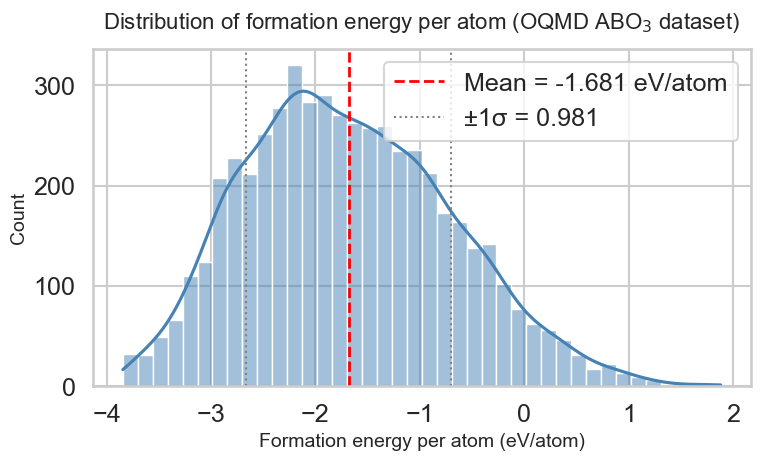

In [15]:
# Formation Energy Distribution Plot
sns.set(style="whitegrid", context="talk", font_scale=1.1)

plt.figure(figsize=(8, 5))
sns.histplot(df_clean[energy_col], bins=40, kde=True, color="steelblue")

# 计算平均值与标准差
mean_fe = df_clean[energy_col].mean()
std_fe = df_clean[energy_col].std()

# 添加竖线和标注
plt.axvline(mean_fe, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_fe:.3f} eV/atom")
plt.axvline(mean_fe + std_fe, color="gray", linestyle=":", linewidth=1.5, label=f"±1σ = {std_fe:.3f}")
plt.axvline(mean_fe - std_fe, color="gray", linestyle=":", linewidth=1.5)

# 标注坐标轴与标题（论文风格）
plt.xlabel("Formation energy per atom (eV/atom)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of formation energy per atom (OQMD ABO$_3$ dataset)",fontsize=16, pad=15)
plt.legend()
plt.tight_layout()
plt.show()

# Q3-Publicly available research data between MP and OQMD datasets

In [16]:
# 提取两个数据集中化学式列（去除空值，并转为字符串）
mp_formulas = set(df["formula_pretty"].dropna().astype(str).str.strip())
oqmd_formulas = set(df_clean["Chemical formula"].dropna().astype(str).str.strip())

# 找出共有化学式
common_formulas = mp_formulas.intersection(oqmd_formulas)

# 打印结果
print(f"Number of unique ABO3 formulas in MP dataset: {len(mp_formulas)}")
print(f"Number of unique ABO3 formulas in OQMD dataset: {len(oqmd_formulas)}")
print(f"Number of common ABO3 formulas in both datasets: {len(common_formulas)}")

# 打印前几个共有的化学式
print("\nExamples of common formulas:")
print(sorted(list(common_formulas))[:20])

Number of unique ABO3 formulas in MP dataset: 1390
Number of unique ABO3 formulas in OQMD dataset: 5276
Number of common ABO3 formulas in both datasets: 1203

Examples of common formulas:
['AcAlO3', 'AcBO3', 'AcCrO3', 'AcCuO3', 'AcFeO3', 'AcGaO3', 'AcMgO3', 'AcMnO3', 'AcNiO3', 'AcPdO3', 'AcScO3', 'AcSiO3', 'AcTiO3', 'AcVO3', 'AgAsO3', 'AgAuO3', 'AgBO3', 'AgBiO3', 'AgGeO3', 'AgPbO3']


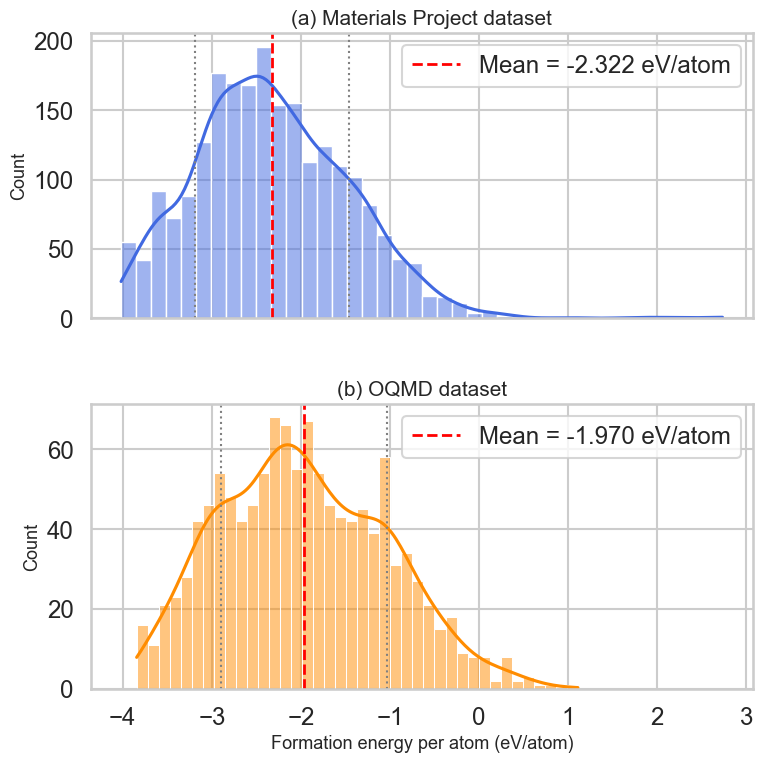

In [17]:
#筛选共有化学式子集
df_common_mp = df[df["formula_pretty"].isin(common_formulas)] #检查DataFrame中某列的每个元素是否包含在指定的列表/集合中
df_common_oqmd = df_clean[df_clean["Chemical formula"].isin(common_formulas)]

#提取形成能数据列
mp_energy = df_common_mp["formation_energy_per_atom"].astype(float) #转化数据形式
oqmd_energy = df_common_oqmd["Formation energy [eV/atom]"].astype(float)

#设置绘图风格
sns.set(style="whitegrid", context="talk", font_scale=1.05)

#创建上下两个子图
fig, axes = plt.subplots(2,1, figsize=(8,8),sharex=True)

# (a) Materials Project 
sns.histplot(mp_energy, bins=40, kde=True, ax=axes[0], color="royalblue")
mean_mp = mp_energy.mean()
std_mp = mp_energy.std()
axes[0].axvline(mean_mp, color="red", linestyle="--", linewidth=2,
                label=f"Mean = {mean_mp:.3f} eV/atom")
axes[0].axvline(mean_mp + std_mp, color="gray", linestyle=":", linewidth=1.5)
axes[0].axvline(mean_mp - std_mp, color="gray", linestyle=":", linewidth=1.5)
axes[0].set_title("(a) Materials Project dataset", fontsize=15)
axes[0].set_ylabel("Count", fontsize=13)
axes[0].legend()

# (b) OQMD 
sns.histplot(oqmd_energy, bins=40, kde=True, ax=axes[1], color="darkorange")
mean_oq = oqmd_energy.mean()
std_oq = oqmd_energy.std()
axes[1].axvline(mean_oq, color="red", linestyle="--", linewidth=2,
                label=f"Mean = {mean_oq:.3f} eV/atom")
axes[1].axvline(mean_oq + std_oq, color="gray", linestyle=":", linewidth=1.5)
axes[1].axvline(mean_oq - std_oq, color="gray", linestyle=":", linewidth=1.5)
axes[1].set_title("(b) OQMD dataset", fontsize=15)
axes[1].set_xlabel("Formation energy per atom (eV/atom)", fontsize=13)
axes[1].set_ylabel("Count", fontsize=13)
axes[1].legend()

#调整布局与整体标题
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

##### Varification through scipy.stats.ttest_ind

In [18]:
''' 
假设检验案例 
假设有两种学习方法 
A类学生用传统学习方法学习并考试 
B类学生用新方法学习并考试 
我们要判断两种方法是否有明确区别 
原假设：传统方法和新方法学习的学生成绩相等 
备择假设：传统方法和新方法学习的学生成绩不相等 
''' 

from scipy import stats
import numpy as np

'''
Materials Project与 OQMD 报告的形成能
df_common_mp = df[df["formula_pretty"].isin(common_formulas)] 
df_common_oqmd = df_clean[df_clean["Chemical formula"].isin(common_formulas)]

mp_energy = df_common_mp["formation_energy_per_atom"].astype(float)
oqmd_energy = df_common_oqmd["Formation energy [eV/atom]"].astype(float) # 确保使用数值列而不是整个DataFrame
↑要用下面这个数值型进行处理
'''


# 两种方法，两种方法计算的 t_stat 应该相同 
# 直接调用 scipy 计算 t 检验 

significance_level_alpha = 0.05 #1-0.95=0.05

# 使用提取的数值列进行t检验
t_stat_scipy, p_scipy = stats.ttest_ind(mp_energy, oqmd_energy, equal_var=False, alternative='two-sided')

# 手动计算验证
mean_df_common_mp = np.mean(mp_energy)
mean_df_common_oqmd = np.mean(oqmd_energy)
var_df_common_mp = np.var(mp_energy, ddof=1)  # 无偏样本方差
var_df_common_oqmd = np.var(oqmd_energy, ddof=1)
n_df_common_mp = len(mp_energy)
n_df_common_oqmd = len(oqmd_energy)

t_stat_manual = (mean_df_common_mp - mean_df_common_oqmd) / np.sqrt(var_df_common_mp/n_df_common_mp + var_df_common_oqmd/n_df_common_oqmd)

print(f"scipy计算结果: {t_stat_scipy}")
print(f"手动计算结果: {t_stat_manual}")
print(f"p值: {p_scipy}")

scipy计算结果: -10.840282425897957
手动计算结果: -10.840282425897957
p值: 9.610987535505628e-27


In [19]:
# 临界值 
degree_of_freedom =n_df_common_mp + n_df_common_oqmd - 2 
# 查表（注意需要双侧检验，查表用的是significance_level_alpha/2） 
critical_value = stats.t.ppf(1.0-significance_level_alpha/2, degree_of_freedom) 

# 假设判断 
if abs(t_stat_manual) > critical_value: 
    print("根据 t 值判断:拒绝原假设") 
else: 
    print("根据 t 值判断:接受原假设") 
# 也可以根据p值判断 
if p_scipy < significance_level_alpha: 
    print("根据 p 值判断:拒绝原假设") 
else: 
    print("根据 p 值判断:接受原假设")

根据 t 值判断:拒绝原假设
根据 p 值判断:拒绝原假设


In [20]:
print("MP mean:", np.mean(mp_energy))
print("OQMD mean:", np.mean(oqmd_energy))
print("Mean difference (MP - OQMD):", np.mean(mp_energy) - np.mean(oqmd_energy))
print("MP std:", np.std(mp_energy, ddof=1))
print("OQMD std:", np.std(oqmd_energy, ddof=1))
print("Sample sizes:", len(mp_energy), len(oqmd_energy))

MP mean: -2.321996534220268
OQMD mean: -1.9695411471321698
Mean difference (MP - OQMD): -0.3524553870880982
MP std: 0.8668522736505379
OQMD std: 0.9307815185113764
Sample sizes: 2230 1203


| 指标 | Materials Project (MP) | OQMD | 备注 |
| :--- | :--- | :--- | :--- |
| 样本均值 (eV/atom) | -2.322 | -1.970 | MP 更负 (更稳定) |
| 差值 (MP - OQMD) | -0.352 | — | 平均形成能相差约 0.35 eV/atom |
| 标准差 | 0.867 | 0.931 | 组内波动接近 |
| 样本数 | 2230 | 1203 | 均为大样本 |
| t 统计量 | -10.84 | — | 极大 (差异显著) |
| p 值 | 9.6×10⁻²⁷ | — | 远小于 0.05 |

### Analysis
#### 1.统计推断结论

在显著性水平 $\alpha = 0.05$ 下：

$$p = 9.6 \times 10^{-27} \ll 0.05 \implies \text{拒绝原假设 } H_0: \mu_{MP} = \mu_{OQMD}$$

**结论：**

在 $95\%$ 置信水平下, Materials Project 与 OQMD 报告的形成能均值存在极显著的差异。

并且由于 $t < 0$, 说明：

Materials Project 的形成能平均值显著低于 OQMD。

即, MP 给出的形成能比 OQMD 更负, 表示在 MP 中材料看起来“更稳定”。


#### 2.差异的数量级（效应量与置信区间）

我们可以估算差异的效应量 (Cohen's d)以及 $95\%$ 置信区间:

1. 合并标准差

$$s_p = \sqrt{\frac{(n_{MP} - 1)s_{MP}^2 + (n_{OQMD} - 1)s_{OQMD}^2}{n_{MP} + n_{OQMD} - 2}} \approx 0.894$$

2. Cohen's d

$$d = \frac{\bar{x}_{MP} - \bar{x}_{OQMD}}{s_p} = \frac{-0.352}{0.894} \approx -0.394$$

效应量 $|d| \approx 0.39$ 属于中等偏小差异。

差异显著 ($p$ 极小)，但在实际能量量尺度上属于系统性偏差而非巨大差距。

3. $95\%$ 置信区间 (Welch 公式近似)

$$CI_{95\%} = -0.352 \pm t_{0.975,\nu} \sqrt{\frac{s_{MP}^2}{n_{MP}} + \frac{s_{OQMD}^2}{n_{OQMD}}}$$

数值代入 (自由度 $\nu \approx 2400$) :

$$CI \approx [-0.420, -0.285]$$

即：

我们有 $95\%$ 的信心认为，MP 的形成能比 OQMD 平均低 **$0.29 \sim 0.42 \text{ eV/atom}$**。

### Summary

使用 Welch 双样本 t 检验（不假定方差齐性）对 Materials Project 与 OQMD 的形成能数据进行统计比较。结果显示两数据库形成能均值存在极显著差异 (t = -10.84, p = 9.6×10⁻²⁷)，在 95% 置信区间下，MP 的形成能比 OQMD 平均低 0.29–0.42 eV/atom。效应量 (Cohen’s d ≈ 0.39) 表明该差异在统计上显著、物理上属于中等偏小偏移。该系统性差异可能源于两数据库在交换–关联泛函、元素参考能、+U 修正及计算流程等方面的不一致。进一步分析可针对不同化学体系或采用配对差值法定量评估偏差来源。